In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("/Users/alex/Downloads/esa-adb-challenge (1)/train.parquet")
print(df.shape)
print(df.dtypes)
df.head(5)

(14728321, 89)
id                   int64
channel_1          float32
channel_10         float32
channel_11         float32
channel_12         float32
                    ...   
telecommand_376    float64
telecommand_38     float64
telecommand_39     float64
telecommand_40     float64
is_anomaly           uint8
Length: 89, dtype: object


,id,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,...,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40,is_anomaly
0,0,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,3,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,4,0.13791,0.0,0.0,0.317175,0.371764,0.297205,0.130113,0.766769,0.349474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [2]:
channels = [f"channel_{i}" for i in range(41, 47)]
X = df[channels]
y = df["is_anomaly"]

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.01,  # tune later
    random_state=42
)

model.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [5]:
scores = model.decision_function(X_scaled)   # higher = more normal
preds = model.predict(X_scaled)              # -1 = anomaly, 1 = normal

# convert to 0/1
preds_binary = (preds == -1).astype(int)

In [6]:
from sklearn.metrics import classification_report

print(classification_report(y, preds_binary))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95  13184217
           1       1.00      0.10      0.17   1544104

    accuracy                           0.91  14728321
   macro avg       0.95      0.55      0.56  14728321
weighted avg       0.91      0.91      0.87  14728321



/Users/alex/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


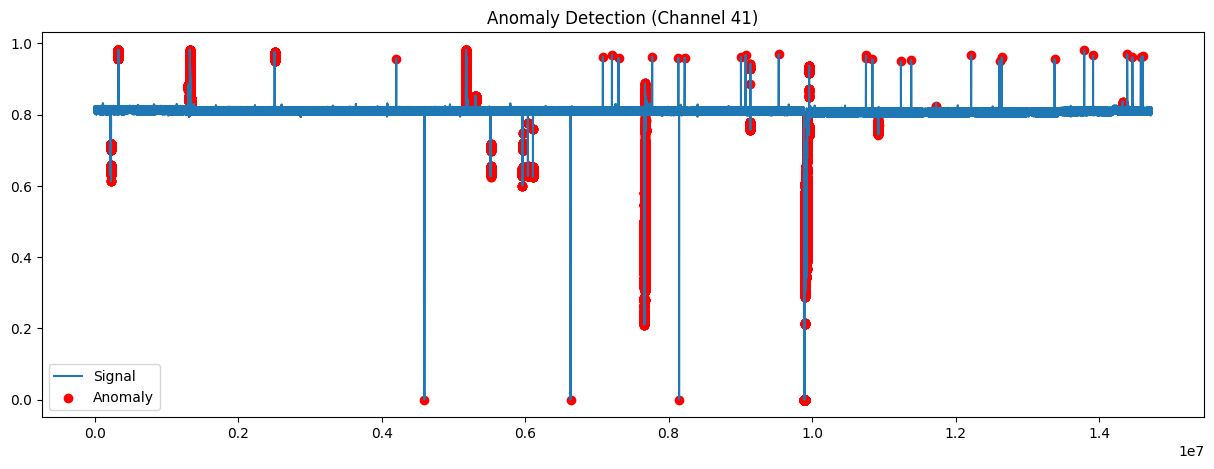

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(X.index, X[channels[0]], label="Signal")

# plot anomalies
anomalies = X.index[preds_binary == 1]
plt.scatter(anomalies, X.loc[anomalies, channels[0]], color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection (Channel 41)")
plt.show()

In [8]:
X_feat = X.copy()

for col in channels:
    X_feat[f"{col}_mean_10"] = X[col].rolling(10).mean()
    X_feat[f"{col}_std_10"] = X[col].rolling(10).std()

X_feat = X_feat.dropna()

In [9]:
y_aligned = y.loc[X_feat.index]

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

In [11]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.01,  # we will override this via threshold anyway
    random_state=42
)

model.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [12]:
scores = model.decision_function(X_scaled)

In [13]:
import numpy as np

threshold = np.percentile(scores, 5)  # try 3, 5, 7, 10
preds_binary = (scores < threshold).astype(int)

In [14]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_aligned, preds_binary)
recall = recall_score(y_aligned, preds_binary)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

Precision: 0.363
Recall: 0.173


In [15]:
percentiles = [1, 3, 5, 7, 10]

for p in percentiles:
    threshold = np.percentile(scores, p)
    preds = (scores < threshold).astype(int)

    precision = precision_score(y_aligned, preds)
    recall = recall_score(y_aligned, preds)

    print(f"{p}% → Precision: {precision:.3f}, Recall: {recall:.3f}")

1% → Precision: 0.998, Recall: 0.095
3% → Precision: 0.498, Recall: 0.142
5% → Precision: 0.363, Recall: 0.173
7% → Precision: 0.299, Recall: 0.200
10% → Precision: 0.248, Recall: 0.237


/Users/alex/.pyenv/versions/3.10.6/envs/sentinel/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


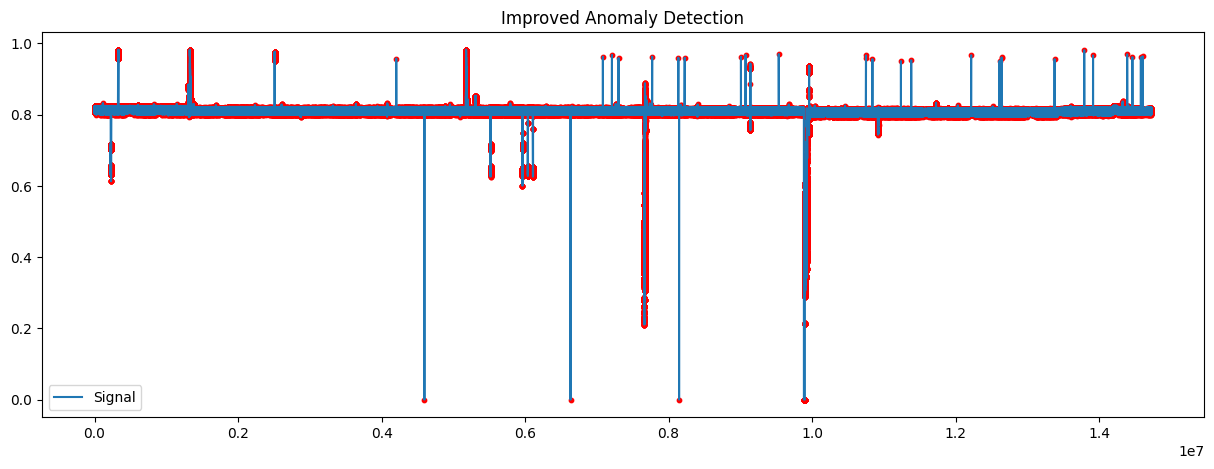

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(X_feat.index, X_feat[channels[0]], label="Signal")

anomalies = X_feat.index[preds_binary == 1]
plt.scatter(anomalies, X_feat.loc[anomalies, channels[0]], color='red', s=10)

plt.legend()
plt.title("Improved Anomaly Detection")
plt.show()